In [ ]:
# this file will test the XFuse Module on some example porespy data using DINOv3


In [ ]:
import os
torch_dir = '/dls/science/groups/imaging/infuse/XRDCT_Fusion/torch_cache/'
os.environ["HUGGINGFACE_HUB_CACHE"] = torch_dir
os.environ["TORCH_HOME"] = torch_dir
os.environ["HF_HUB_CACHE"] = torch_dir
os.environ["HF_HOME"] = torch_dir

from x_fuse.utils import get_multiphase, downsample_xrdct, xrd_to_tensor
from x_fuse.fusion import XFuse

import hr_dv2.transform as tr
from hr_dv2.utils import do_single_pca, rescale_pca
import torchvision.transforms as transforms
from hr_dv2.high_res import HighResDV2

import numpy as np
import porespy as ps
import matplotlib.pyplot as plt
import porespy as ps
from PIL import Image, ImageOps

import torch
import torch.nn.functional as F
import torchvision.transforms as T

# refining segmentation
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import cv2

# CLIP for NLP-based scoring
import open_clip



In [13]:
# set the HYPERPARAMS

# dataset

IMG_SIZE = 224
N_SAMPLES = 10

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# DINO Model
DINO_MODEL = "nope_dv3_vits16plus_1625" #DINOv3
# MODEL_PATH = "/dls/science/groups/imaging/infuse/XRDCT_Fusion/dinosaw-env/test/20260413_1615_dinov2_GIANT/best_model.pth" #DINOv2
MODEL_PATH = "/dls/science/groups/imaging/infuse/XRDCT_Fusion/dinosaw-env/models/dinov3_SMALL_REG_1625_plus_alibi/best_model.pth" #DINOv3
# MODEL_PATH = "/dls/science/groups/imaging/infuse/DINOv3/Models/alibi_dv2_vits14_reg.pth"

CHK_PATH = "/dls/science/groups/imaging/infuse/DINOv3/Models/"
LIB_PATH = "/dls/science/groups/imaging/infuse/DINOv3/dinov3/"

PATCH_SIZE = 14 if "dinov2" in DINO_MODEL else 16
STRIDE = 4
PATCH_H, PATCH_W = IMG_SIZE // PATCH_SIZE, IMG_SIZE // PATCH_SIZE
FUSION_METHOD = 'gating'
LOSS_FN = 'bce'
TOP_K = 10
INVERT = False


In [14]:
# create the dataset

def get_ps_images():
    ps_dict = {"blobs": ps.generators.blobs, "rand_spheres": ps.generators.random_spheres}

    im1 = ps_dict["blobs"]
    im2 = ps_dict["rand_spheres"]

    im1_kwargs = {'shape': [IMG_SIZE, IMG_SIZE], 'blobiness': 0.5, 'porosity': 0.1}
    im2_kwargs = {'r': 40, 'clearance': 10}

    gray, phase_A_masks, phase_B_masks = get_multiphase(im1, im1_kwargs, im2, im2_kwargs, extract_spheres=True, vis=False, dataset_size=10)
    gray_imgs, low_A, low_B = downsample_xrdct(gray, phase_A_masks, phase_B_masks, factor=10, vis=False)

    return gray_imgs, low_A, low_B

In [15]:
gray_imgs, low_A, low_B = get_ps_images()

In [16]:
def get_single_imgs(idx=0, gray_imgs=gray_imgs, low_A=low_A, low_B=low_B):
    xct_img = gray_imgs[idx]
    xrd_A = low_A[idx]
    xrd_B = low_B[idx]

    return xct_img, xrd_A, xrd_B

In [17]:
# refine the data

xct_img, xrd_A, xrd_B = get_single_imgs(idx=-1)

In [18]:
def invert_image(image, vis=False):
    inverted = np.ones_like(image) - image
    if vis:
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(image, cmap='gray')
        ax[0].set_title('Original Image')
        ax[0].axis('off')
        ax[1].imshow(inverted, cmap='gray')
        ax[1].set_title('Inverted Image')
        ax[1].axis('off')
        plt.show()

    return np.ones_like(image) - image

if INVERT:
    xct_img = invert_image(xct_img, vis=True)
    xrd_A = invert_image(xrd_A, vis=True)
    xrd_B = invert_image(xrd_B, vis=True)


In [19]:
def load_img(img, transform):
    unnormalize = transforms.Normalize(
        mean=(-0.485/0.229, -0.456/0.224, -0.406/0.225),
        std=(1/0.229, 1/0.224, 1/0.225),
    )
    img_uint8 = (img * 255).astype(np.uint8)
    image = ImageOps.autocontrast(Image.fromarray(img_uint8).convert("RGB"))
    tensor = transform(image)
    trans_img = transforms.ToPILImage()(unnormalize(tensor))
    return tensor, trans_img

In [20]:
h, w = xct_img.shape
print(f"XCT image shape: {xct_img.shape}, Phase A mask shape: {xrd_A.shape}, Phase B mask shape: {xrd_B.shape}")

xct_img_tr = tr.closest_crop(xct_img, PATCH_H, PATCH_W)
xct_img_tr = tr.get_input_transform(IMG_SIZE, IMG_SIZE)
xct_tensor, xct_image = load_img(xct_img, xct_img_tr)
print("XCT Tensor Shape: ", xct_tensor.shape)

# move xct_tensor and phase maps to device as tensors

xct_tensor = xct_tensor.to(torch.float16).to(DEVICE)

xrd_A_tensor = xrd_to_tensor(xrd_A, DEVICE)
xrd_B_tensor = xrd_to_tensor(xrd_B, DEVICE)

print("XCT Device:", xct_tensor.device, "Phase A Device:", xrd_A_tensor.device, "Phase B Device:", xrd_B_tensor.device)

XCT image shape: (224, 224), Phase A mask shape: (22, 22), Phase B mask shape: (22, 22)
XCT Tensor Shape:  torch.Size([3, 224, 224])
XCT Device: cuda:0 Phase A Device: cuda:0 Phase B Device: cuda:0


In [21]:
# set the transforms for the augmentations
shift_dists = [i for i in range(1,3)]

fwd_shift, inv_shift = tr.get_shift_transforms(shift_dists, 'Moore')
fwd_flip, inv_flip = tr.get_flip_transforms()
fwd, inv = tr.combine_transforms(fwd_shift, fwd_flip, inv_shift, inv_flip)

In [22]:
# Phase A

net_A = XFuse(
    DINO_MODEL,
    FUSION_METHOD,
    stride=STRIDE,
    pca_dim=-1,
    track_grad=False,
    dtype=torch.float16,
    device=DEVICE,
    loss_fn=LOSS_FN,
    model_path = MODEL_PATH,
    # chk_path = CHK_PATH if "dv3" in DINO_MODEL else None,
    chk_path = MODEL_PATH if "dv3" in DINO_MODEL else None,
    lib_path = LIB_PATH if "dv3" in DINO_MODEL else None
)
net_A.set_xrd_transforms(xrd_A_tensor, fwd, inv)
feats_A = net_A.forward_sequential(xct_tensor, top_k=TOP_K)

# active channels
active_feats_A = feats_A[0][feats_A[0].abs().sum(dim=(1,2)) > 0]
print(f"Active channels in Phase A: {active_feats_A.shape[0]} out of {feats_A[0].shape[0]}")

feats_np_A = tr.to_numpy(feats_A[0])
feats_flat_A = tr.flatten(feats_np_A, feats_np_A.shape[1], feats_np_A.shape[2], feats_np_A.shape[0])
pcaed_A = do_single_pca(feats_flat_A, 3, n_samples=5000)
rescaled_A = rescale_pca(pcaed_A)    


[20:54:00] WARNING  Warning: You are sending unauthenticated requests to the HF Hub. Please set a      ]8;id=2802856;file:///dls/science/groups/imaging/infuse/XRDCT_Fusion/X-FUSE/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_http.py\_http.py]8;;\:]8;id=2802857;file:///dls/science/groups/imaging/infuse/XRDCT_Fusion/X-FUSE/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_http.py#904\904]8;;\
                    HF_TOKEN to enable higher rate limits and faster downloads.                                    

Active channels in Phase A: 47 out of 384


In [24]:
# Phase B

net_B = XFuse(
    DINO_MODEL,
    FUSION_METHOD,
    stride=STRIDE,
    pca_dim=-1,
    track_grad=False,
    dtype=torch.float16,
    device=DEVICE,
    loss_fn=LOSS_FN,
    model_path = MODEL_PATH,
    # chk_path = CHK_PATH if "dv3" in DINO_MODEL else None,
    chk_path = MODEL_PATH if "dv3" in DINO_MODEL else None,
    lib_path = LIB_PATH if "dv3" in DINO_MODEL else None
)
net_B.set_xrd_transforms(xrd_B_tensor, fwd, inv)
feats_B = net_B.forward_sequential(xct_tensor, top_k=TOP_K)

# extract non-zero channels
active_feats_B = feats_B[0][feats_B[0].abs().sum(dim=(1,2)) > 0]
print(f"Active channels in Phase B: {active_feats_B.shape[0]} out of {feats_B[0].shape[0]}")

feats_np_B = tr.to_numpy(active_feats_B)
feats_flat_B = tr.flatten(feats_np_B, feats_np_B.shape[1], feats_np_B.shape[2], feats_np_B.shape[0])
pcaed_B = do_single_pca(feats_flat_B, 3, n_samples=5000)
rescaled_B = rescale_pca(pcaed_B)

Active channels in Phase B: 77 out of 384


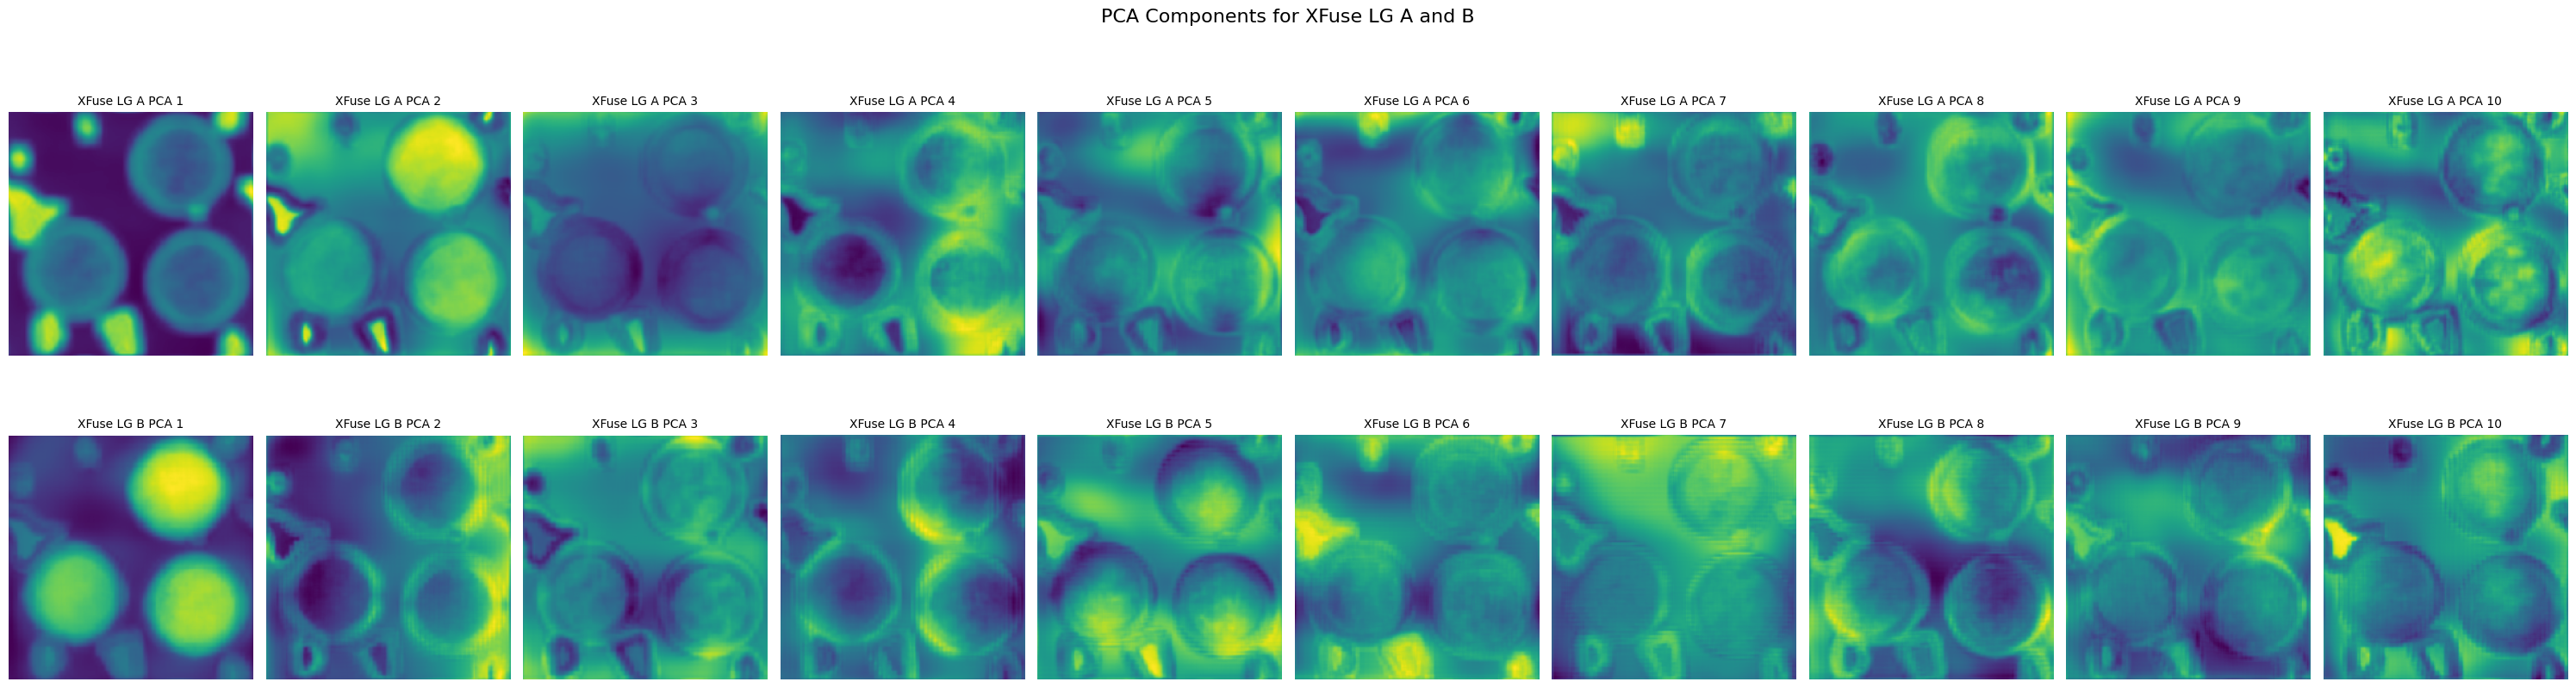

In [25]:
pcaed_A = rescale_pca(do_single_pca(feats_flat_A, 10, n_samples=5000))
pcaed_B = rescale_pca(do_single_pca(feats_flat_B, 10, n_samples=5000))
# pcaed_2 = rescale_pca(do_single_pca(feats_flat2, 10, n_samples=5000)



fig, axs = plt.subplots(nrows=2, ncols=10, figsize=(30, 9))

for i in range(10):
    axs[0, i].imshow(pcaed_A[:, i].reshape(IMG_SIZE, IMG_SIZE), cmap='viridis')
    axs[1, i].imshow(pcaed_B[:, i].reshape(IMG_SIZE, IMG_SIZE), cmap='viridis')
    axs[0, i].set_title(f'XFuse LG A PCA {i+1}', fontsize=10)
    axs[1, i].set_title(f'XFuse LG B PCA {i+1}', fontsize=10)
    axs[0, i].set_axis_off()
    axs[1, i].set_axis_off()
plt.suptitle('PCA Components for XFuse LG A and B', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
print(min(pcaed_A[:,0]), max(pcaed_A[:,0]))

In [ ]:

threshold = 0.2

mapA = pcaed_A[:, 0].reshape(IMG_SIZE, IMG_SIZE) > threshold
mapB = pcaed_B[:, 0].reshape(IMG_SIZE, IMG_SIZE) > threshold

fig, ax = plt.subplots(2,3, figsize=(18,6))
ax[0,0].imshow(xct_img, cmap='gray');        ax[0,0].set_title('XCT')
ax[0,1].imshow(mapA, cmap='gray');       ax[0,1].set_title('XFuse PCA 1 - Phase A')
ax[0,2].imshow(mapB, cmap='gray');       ax[0,2].set_title('XFuse PCA 1 - Phase B')


ax[1,0].imshow(xct_img, cmap='gray')
ax[1,1].imshow(xrd_A, cmap='gray', interpolation='lanczos');      ax[1,1].set_title(f'XRD Phase A (Upsampled)')
ax[1,2].imshow(xrd_B, cmap='gray', interpolation='lanczos');     ax[1,2].set_title(f'XRD Phase B (Upsampled)')

plt.tight_layout()
plt.show()

In [ ]:
SAM2_FOLDER = "//dls/science/groups/imaging/infuse/SAM2/" # ensure double //
SAM2_MODEL = "sam2.1_hiera_small"

sam2 = build_sam2(f"{SAM2_FOLDER}{SAM2_MODEL}.yaml", f"{SAM2_FOLDER}{SAM2_MODEL}.pt", device=DEVICE)
predictor = SAM2ImagePredictor(sam2)

In [ ]:
xct_pil = Image.fromarray((xct_img * 255).astype(np.uint8)).convert("RGB")
xct_pil = ImageOps.autocontrast(xct_pil)
predictor.set_image(np.array(xct_pil))

mask_input = cv2.resize(mapA.astype(np.float32), (256, 256))[None]  # (1, 256, 256)
mask_input = (mask_input * 2 - 1) * 10  # binary → ±10 logits

with torch.inference_mode():
    masks, scores, _ = predictor.predict(
        mask_input=mask_input,
        multimask_output=False,
    )
best_mask = masks[0].astype(bool)


xrd_mask_input = cv2.resize(xrd_A.astype(np.float32), (256, 256))[None]  # (1, 256, 256)
xrd_mask_input = (xrd_mask_input * 2 - 1) * 10  # binary → ±10 logits
with torch.inference_mode():
    masks_xrd, scores_xrd, _ = predictor.predict(
        mask_input=xrd_mask_input,
        multimask_output=False,
    )
best_mask_xrd = masks_xrd[0].astype(bool)
best_mask_xrd_resized = cv2.resize(
    best_mask_xrd.astype(np.uint8),
    (xrd_B.shape[1], xrd_B.shape[0]),
    interpolation=cv2.INTER_NEAREST
).astype(bool)

def overlay_mask(xct, mask, color=(1, 0.2, 0.2), alpha=0.4):
    mask = mask.astype(bool)
    rgb = np.stack([xct] * 3, axis=-1)
    overlay = rgb.copy()
    overlay[mask] = (1 - alpha) * rgb[mask] + alpha * np.array(color)
    return np.clip(overlay, 0.0, 1.0)


for best_mask in masks:
    fig, axs = plt.subplots(2, 3, figsize=(18, 6))
    axs[0,0].imshow(xct_img, cmap='gray');                 axs[0,0].set_title('XCT')
    axs[0,1].imshow(mapA, cmap='gray');                    axs[0,1].set_title('XFuse mask (coarse)')
    axs[0,2].imshow(overlay_mask(xct_img, best_mask));     axs[0,2].set_title(f'SAM2 refined (score={scores[0]:.3f})')
    axs[1,0].imshow(xct_img, cmap='gray');                 axs[1,0].set_title('XCT')
    axs[1,1].imshow(xrd_A, cmap='gray', interpolation='lanczos');     axs[1,1].set_title('XRD Phase B')
    axs[1,2].imshow(overlay_mask(xct_img, best_mask_xrd.astype(bool)), cmap='gray', interpolation='lanczos');     axs[1,2].set_title(f'SAM2 refined on XRD (score={scores_xrd[0]:.3f})')

    for ax in axs.flat: ax.set_axis_off()
    plt.tight_layout()

In [ ]:
xct_pil = Image.fromarray((xct_img * 255).astype(np.uint8)).convert("RGB")
xct_pil = ImageOps.autocontrast(xct_pil)
predictor.set_image(np.array(xct_pil))

mask_input = cv2.resize(mapB.astype(np.float32), (256, 256))[None]  # (1, 256, 256)
mask_input = (mask_input * 2 - 1) * 10  # binary → ±10 logits

with torch.inference_mode():
    masks, scores, _ = predictor.predict(
        mask_input=mask_input,
        multimask_output=False,
    )
best_mask = masks[0].astype(bool)


xrd_mask_input = cv2.resize(xrd_B.astype(np.float32), (256, 256))[None]  # (1, 256, 256)
xrd_mask_input = (xrd_mask_input * 2 - 1) * 10  # binary → ±10 logits
with torch.inference_mode():
    masks_xrd, scores_xrd, _ = predictor.predict(
        mask_input=xrd_mask_input,
        multimask_output=False,
    )
best_mask_xrd = masks_xrd[0].astype(bool)
best_mask_xrd_resized = cv2.resize(
    best_mask_xrd.astype(np.uint8),
    (xrd_B.shape[1], xrd_B.shape[0]),
    interpolation=cv2.INTER_NEAREST
).astype(bool)

def overlay_mask(xct, mask, color=(1, 0.2, 0.2), alpha=0.4):
    mask = mask.astype(bool)
    rgb = np.stack([xct] * 3, axis=-1)
    overlay = rgb.copy()
    overlay[mask] = (1 - alpha) * rgb[mask] + alpha * np.array(color)
    return np.clip(overlay, 0.0, 1.0)


for best_mask in masks:
    fig, axs = plt.subplots(2, 3, figsize=(18, 6))
    axs[0,0].imshow(xct_img, cmap='gray');                 axs[0,0].set_title('XCT')
    axs[0,1].imshow(mapB, cmap='gray');                    axs[0,1].set_title('XFuse mask (coarse)')
    axs[0,2].imshow(overlay_mask(xct_img, best_mask));     axs[0,2].set_title(f'SAM2 refined (score={scores[0]:.3f})')
    axs[1,0].imshow(xct_img, cmap='gray');                 axs[1,0].set_title('XCT')
    axs[1,1].imshow(xrd_B, cmap='gray', interpolation='lanczos');     axs[1,1].set_title('XRD Phase B')
    axs[1,2].imshow(overlay_mask(xct_img, best_mask_xrd.astype(bool)), cmap='gray', interpolation='lanczos');     axs[1,2].set_title(f'SAM2 refined on XRD (score={scores_xrd[0]:.3f})')

    for ax in axs.flat: ax.set_axis_off()
    plt.tight_layout()

In [ ]:
def get_SAM2_score(pca_comp, img_size, predictor: SAM2ImagePredictor, threshold, get_mask=False):
    
    map = pca_comp[:, 0].reshape(img_size, img_size) > threshold

    # run SAM2 predictor to get the initial score
    mask_input = cv2.resize(map.astype(np.float32), (256, 256))[None]  # (1, 256, 256)
    mask_input = (mask_input * 2 - 1) * 10  # binary → ±10 logits


    with torch.inference_mode():
        if not get_mask:
            _, scores, _ = predictor.predict(
                mask_input=mask_input,
                multimask_output=False,
            )
        else:
            masks, scores, _ = predictor.predict(
                mask_input=mask_input,
                multimask_output=False,
            )
    return float(scores[0]) if not get_mask else (masks, float(scores[0]))

def auto_threshold(pca_comp, img_size, predictor: SAM2ImagePredictor, n_iter=10, lr=0.1):
    """
    Function that automatically optimises the threshold value for the best SAM2 score.
    This *should* produce the best segmentation mask for phase based segmentation
    """
    # initialise the threshold value
    init_t = np.median(pca_comp[:, 0])
    init_t = 0.5
    eps = 0.01 * (np.max(pca_comp[:, 0]) - np.min(pca_comp[:, 0]))

    # initial sweep to find starting threshold value, then optimise
    t_range = np.linspace(0,1,20)
    init_t = t_range[0]
    init_score = get_SAM2_score(pca_comp, img_size, predictor, init_t) 
    for t in t_range:
        score = get_SAM2_score(pca_comp, img_size, predictor, t)
        if score > init_score:
            best_score = score
            best_t = t

    init_t = best_t

    t, best_score = init_t, get_SAM2_score(pca_comp, img_size, predictor, init_t)
    history = [(t, best_score)]
    best_t = t

    for i in range(n_iter):
        grad = get_SAM2_score(pca_comp, img_size, predictor, t + eps) - get_SAM2_score(pca_comp, img_size, predictor, t - eps) / (2 * eps)
        t -= lr * grad
        t = max(0, min(1, t))  # clamp to [0, 1]
        score = get_SAM2_score(pca_comp, img_size, predictor, t)
        if score > best_score:
            best_score = score
            best_t = t
            history.append((t, score))

        if abs(score - best_score) < 1e-5:  # early stopping if improvement is small
            break


    best_mask = get_SAM2_score(pca_comp, img_size, predictor, best_t, get_mask=True)[0][0].astype(bool)
    print(f"Best Threshold: {best_t:.4f}, Best Score: {best_score:.4f}")

    return best_mask, best_t, best_score, history



In [ ]:
# lets try the autothresholding

# define SAM2
SAM2_FOLDER = "//dls/science/groups/imaging/infuse/SAM2/" # ensure double //
SAM2_MODEL = "sam2.1_hiera_small"

sam2 = build_sam2(f"{SAM2_FOLDER}{SAM2_MODEL}.yaml", f"{SAM2_FOLDER}{SAM2_MODEL}.pt", device=DEVICE)
predictor = SAM2ImagePredictor(sam2)

# set the predictor image
xct_pil = Image.fromarray((xct_img * 255).astype(np.uint8)).convert("RGB")
xct_pil = ImageOps.autocontrast(xct_pil)
predictor.set_image(np.array(xct_pil))


In [ ]:
bestA, _, _, _ = auto_threshold(pcaed_A, img_size=IMG_SIZE, predictor=predictor, n_iter=1000)
bestB, _, _, _ = auto_threshold(pcaed_B, img_size=IMG_SIZE, predictor=predictor, n_iter=1000) 

def auto_AB_threshold(xct_img, bestA, bestB):

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(xct_img, cmap='gray');                 axs[0].set_title('XCT')
    axs[1].imshow(overlay_mask(xct_img, bestA), cmap='gray');                    axs[1].set_title('SAM2 refined (A)')
    axs[2].imshow(overlay_mask(xct_img, bestB), cmap='gray');     axs[2].set_title(f'SAM2 refined (B)')
    for ax in axs.flat: ax.set_axis_off()
    plt.tight_layout()


In [ ]:
auto_AB_threshold(xct_img, bestA, bestB)

In [ ]:
from skimage.filters import threshold_otsu

pca_A = pcaed_A[:, 0].reshape(IMG_SIZE, IMG_SIZE)
pca_B = pcaed_B[:, 0].reshape(IMG_SIZE, IMG_SIZE)

t_A = threshold_otsu(pca_A)
t_B = threshold_otsu(pca_B)

mapA = pca_A > t_A
mapB = pca_B > t_B

mapA_2 = pca_A > 0.129
mapB_2 = pca_B > 0.05

fig, ax = plt.subplots(3,3, figsize=(18,6))
ax[0,0].imshow(xct_img, cmap='gray');        ax[0,0].set_title('XCT')
ax[0,1].imshow(mapA, cmap='viridis');       ax[0,1].set_title('XFuse mask A (Otsu)')
ax[0,2].imshow(mapB, cmap='viridis');       ax[0,2].set_title('XFuse mask B (Otsu)')
ax[1,0].imshow(xct_img, cmap='gray')
ax[1,1].imshow(mapA_2, cmap='viridis');       ax[1,1].set_title(f'XFuse mask A (thresh={0.129})')
ax[1,2].imshow(mapB_2, cmap='viridis');       ax[1,2].set_title(f'XFuse mask B (thresh={0.05})')
ax[2,0].imshow(xct_img, cmap='gray')
ax[2,1].imshow(xrd_A, cmap='gray', interpolation='lanczos')
ax[2,2].imshow(xrd_B, cmap='gray', interpolation='lanczos')
plt.tight_layout()
plt.show()

In [ ]:
def xct_contrast(threshold, pca_component, xct_img):
    mask = pca_component > threshold
    if mask.sum() == 0 or mask.all():
        return 0.0
    inside  = xct_img[mask].mean()
    outside = xct_img[~mask].mean()
    return abs(inside - outside)

pca_A = pcaed_A[:, 0].reshape(IMG_SIZE, IMG_SIZE)

fig,ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(pca_A, cmap='viridis')
ax[1].imshow(xct_img, cmap='gray')
plt.show()

lo, hi = pca_A.min(), pca_A.max()
thresholds = np.linspace(lo, hi, 50)
scores = [xct_contrast(t, pca_A, xct_img) for t in thresholds]

print(np.argmax(scores))
print(thresholds[np.argmax(scores)])


t_A = thresholds[np.argmax(scores)]
print(t_A)
mapA = pca_A > t_A

plt.imshow(mapA, cmap='gray')
plt.show()